# Exercícios
## 1) Modificar a profundidade da árvore e comparar resultados
**Objetivo:**

Entender como a profundidade (max_depth) influencia o underfitting e o overfitting.

Altere o parâmetro da árvore de decisão:

model = DecisionTreeClassifier(max_depth=3)

E teste diferentes valores:

max_depth = 1;
max_depth = 5;
max_depth = None (profundidade ilimitada)

Para cada profundidade:

1. Treine o modelo.
2. Plote a árvore de decisão.
3. Gere a fronteira de decisão.
4. Calcule as métricas: accuracy, precisão, recall, F1.

**Pergunta final:** Como a profundidade influencia o overfitting e o desempenho no teste?

## 2) Alterar o dataset e reavaliar o modelo
**Objetivo:**

Explorar como diferentes distribuições de dados afetam o comportamento da árvore.

Modifique o bloco:

X, y = make_classification(...)

Testando diferentes configurações:

1. Aumente o ruído dos rótulos
flip_y=0.15
2. Aumente o número de clusters por classe
n_clusters_per_class=2
3. Aumente o número de features informativas
n_features=4
n_informative=4

Para cada cenário:

1. Refaça o treino.
2. Plote (quando possível).
3. Gere a matriz de confusão.
4. Calcule accuracy, precisão, recall e F1.

**Pergunta final:** Em quais condições o modelo piora mais? Por quê?

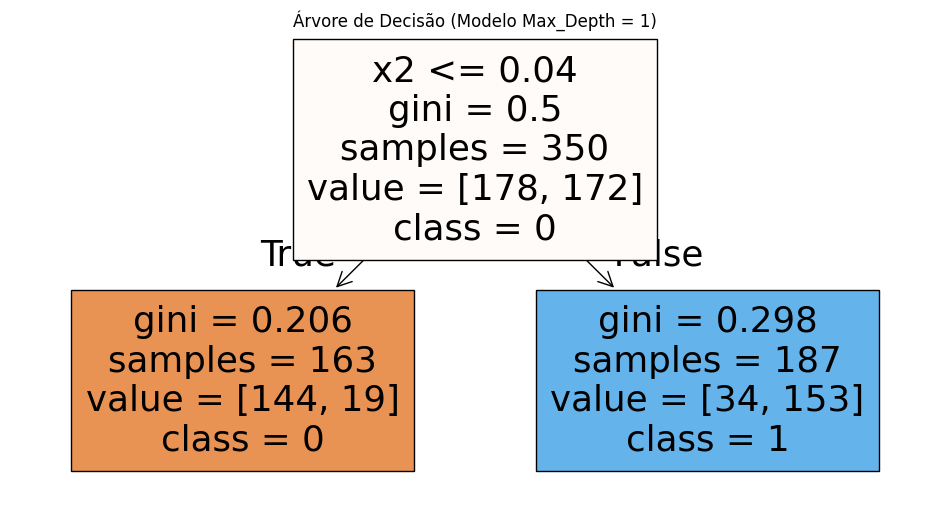

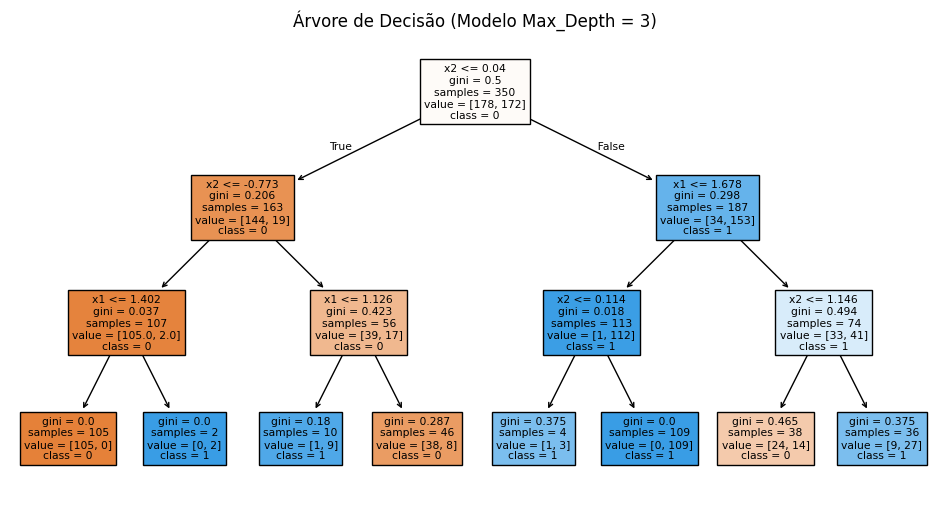

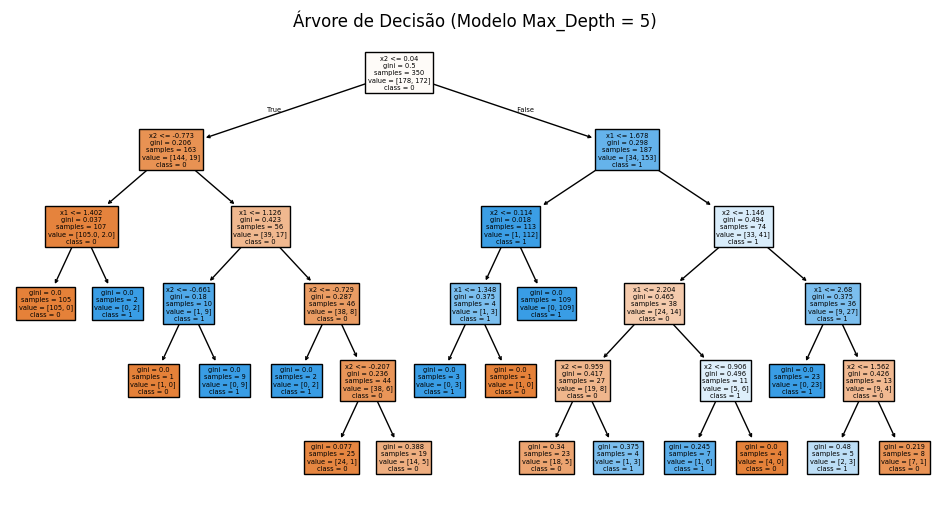

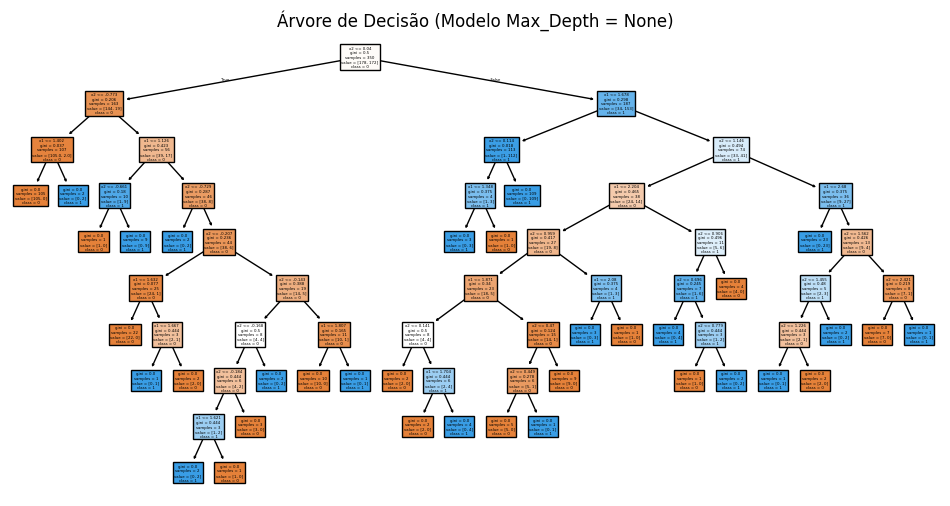

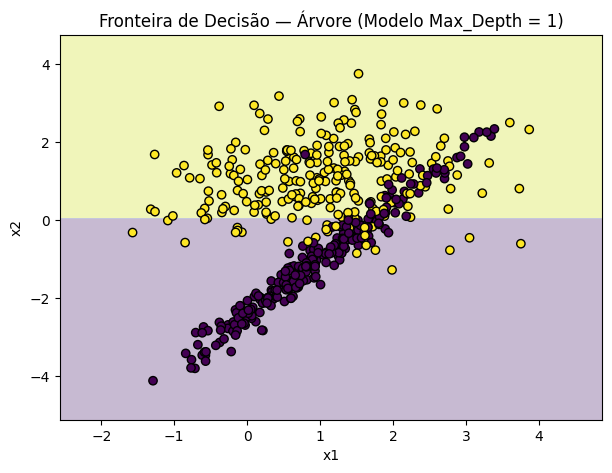

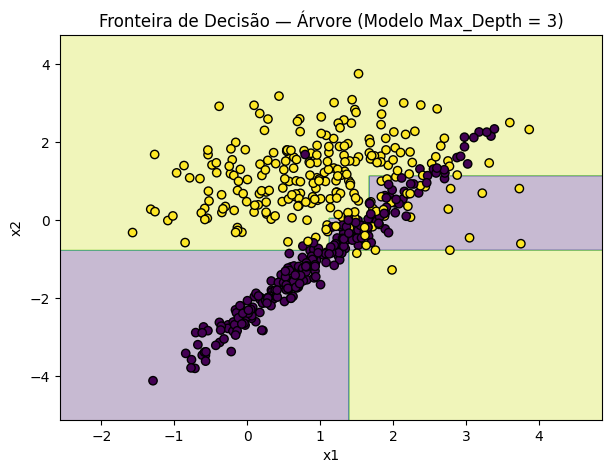

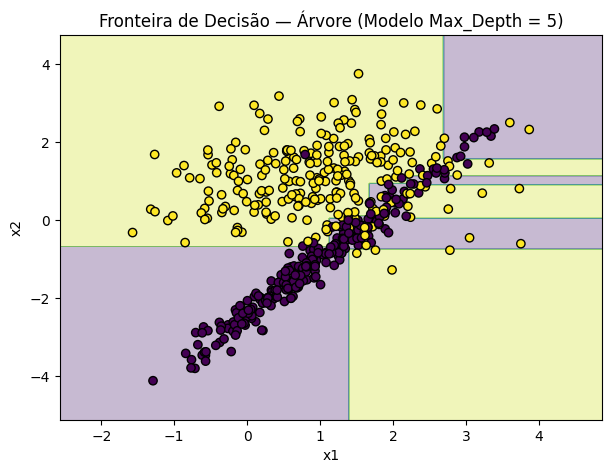

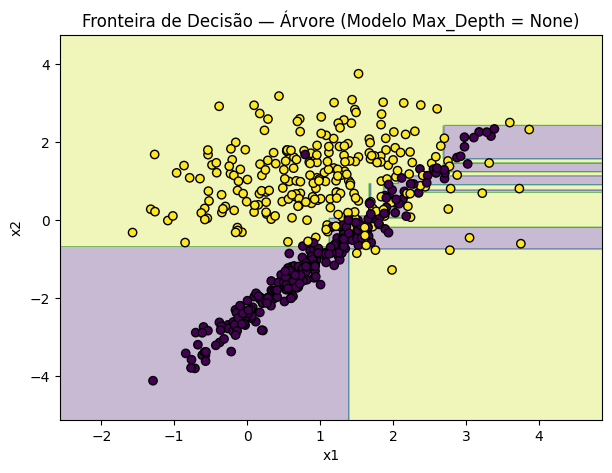

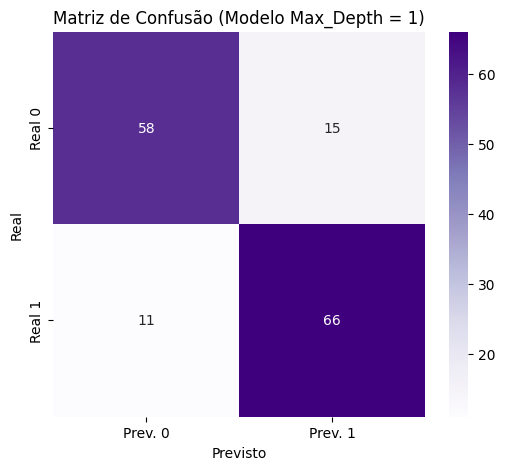

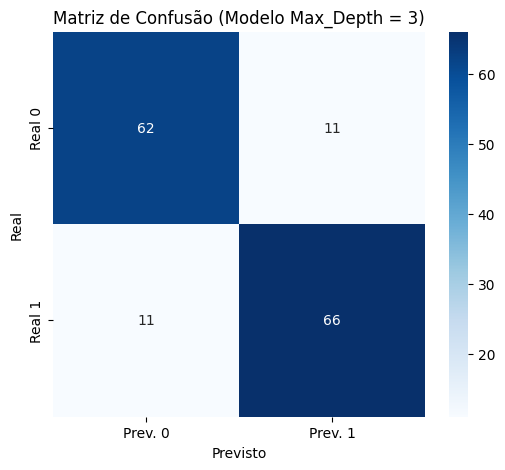

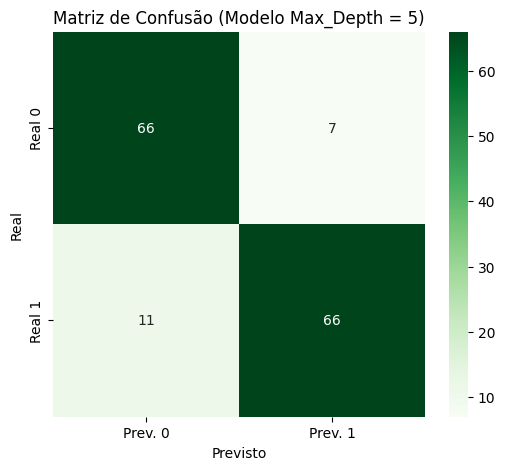

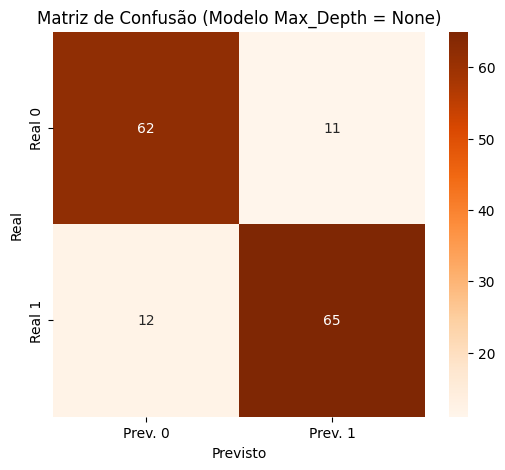

,Modelo,Accuracy,Precisão,Recall,F1-score
0,Max_Depth = 5,0.880,0.904,0.857,0.880
1,Max_Depth = 3,0.853,0.857,0.857,0.857
2,Max_Depth = None,0.847,0.855,0.844,0.850
3,Max_Depth = 1,0.827,0.815,0.857,0.835



Pergunta Final:
O aumento do valor de max_depth eleva a complexidade da árvore, permitindo melhor ajuste aos dados de treino. 
Entretanto, profundidades muito altas tornam o modelo muito sensível a dados diferentes ou ruidosos ou viciado nos dados do treinamento, reduzindo a capacidade de generalização (Overfitting). 
Por outro lado, profundidades muito baixas limitam a capacidade de generalização do modelo (Underfitting). 
Devido a simplicidade dos dados utilizados, todos os modelos apresentaram bom desempenho, mas em cenários mais complexos, a escolha da profundidade impacta significativamente os resultados.


In [15]:
# Exercício 1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# =====================================================
# 1) Gerar dados simples (2 classes)
# =====================================================
# Aumenta o número de amostras como forma de provocar uma variação maior nos diferentes algoritmos criados
X, y = make_classification(n_samples=500, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

# =====================================================
# 2) Dividir em treino e teste
# =====================================================
# Divisão dos dados de exemplo entre treino e teste, de forma a evitar que os modelos fiquem viciados nos dados com que aprenderam
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# =====================================================
# 3) Treinar a árvore
# =====================================================
# Cria os diferentes modelos de algoritmos a serem utilizados no código, variando o número de max depths entre eles
model1 = DecisionTreeClassifier(max_depth=1)
model2 = DecisionTreeClassifier(max_depth=3)
model3 = DecisionTreeClassifier(max_depth=5)
model4 = DecisionTreeClassifier(max_depth=None)

# Coloca os models em uma lista para trabalhar com eles no restante do código evitando repetição
models = [(model1, "Max_Depth = 1", "Purples"), (model2, "Max_Depth = 3", "Blues"), (model3, "Max_Depth = 5", "Greens"), (model4, "Max_Depth = None", "Oranges")]

# Treina todos os modelos com os mesmos valores de X e Y
for model, _, _ in models:
  model.fit(X_train, y_train)

# =====================================================
# 4) Visualizar a Árvore
# =====================================================
# Exibe a árvore de cada um dos modelos treinados
for model, name, _ in models:
  plt.figure(figsize=(12,6))
  plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
  plt.title(f"Árvore de Decisão (Modelo {name})")
  plt.show()
  print()

# =====================================================
# 5) Fronteira de decisão
# =====================================================
# Como os dados utilizados nos 4 modelos são os mesmos, só é necessário calcular o meshgrid uma única vez
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

for model, name, _ in models:
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(7,5))
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

  plt.title(f"Fronteira de Decisão — Árvore (Modelo {name})")
  plt.xlabel("x1")
  plt.ylabel("x2")
  plt.show()
  print()

# =====================================================
# 6) Matriz de Confusão e Métricas de avaliação
# =====================================================
# Cria uma lista para armazenar o resultado dos diferentes modelos treinados
results = []

for model, name, colour in models:
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot=True, fmt="d", cmap=colour,
              xticklabels=["Prev. 0", "Prev. 1"],
              yticklabels=["Real 0", "Real 1"])

  plt.title(f"Matriz de Confusão (Modelo {name})")
  plt.ylabel("Real")
  plt.xlabel("Previsto")
  plt.show()
  print()

  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  results.append({
    "Modelo": name,
    "Accuracy": acc,
    "Precisão": prec,
    "Recall": rec,
    "F1-score": f1
  })

# Exibe uma tabela com os resultados obtidos por cada modelo treinado
df = pd.DataFrame(results).round(3)
# Ordena o dataframe de acordo com a métrica de F1-score, que poderia ser substituida dependendo da aplicação
df = df.sort_values(by="F1-score", ascending=False, ignore_index=True)
display(df)
print()

# Explicação dos resultados obtidos
print("Pergunta Final:")
print("O aumento do valor de max_depth eleva a complexidade da árvore, permitindo melhor ajuste aos dados de treino. \nEntretanto, profundidades muito altas tornam o modelo muito sensível a dados diferentes ou ruidosos ou viciado nos dados do treinamento, reduzindo a capacidade de generalização (Overfitting). \nPor outro lado, profundidades muito baixas limitam a capacidade de generalização do modelo (Underfitting). \nDevido a simplicidade dos dados utilizados, todos os modelos apresentaram bom desempenho, mas em cenários mais complexos, a escolha da profundidade impacta significativamente os resultados.")

Dados com maior ruído: 



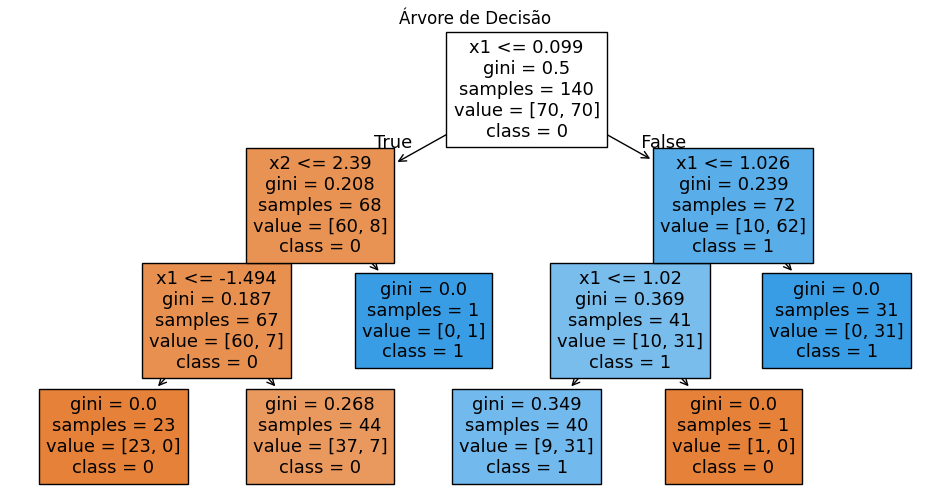

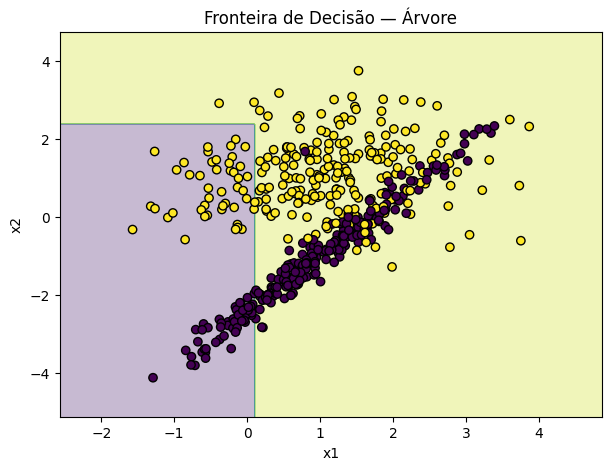

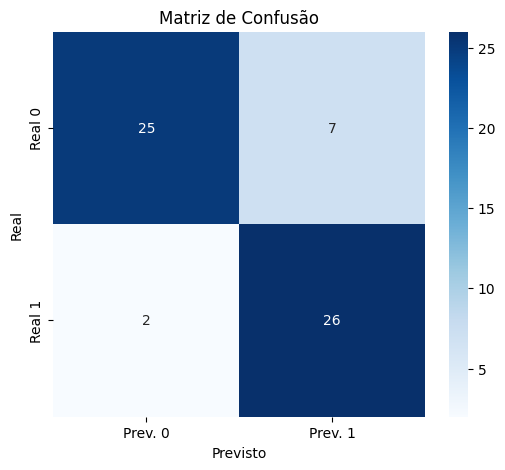


Dados com mais clusters por classe: 



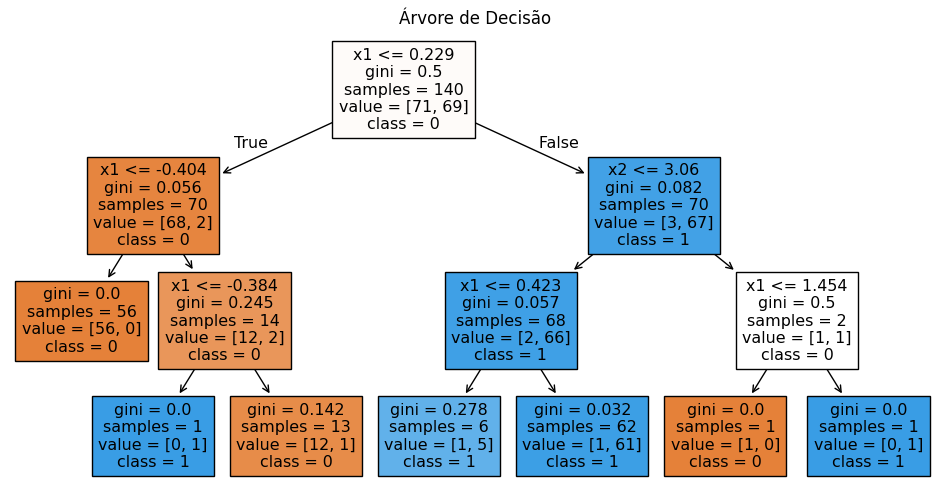

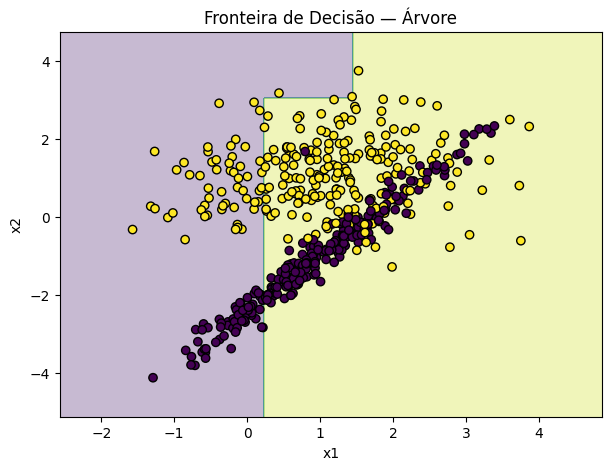

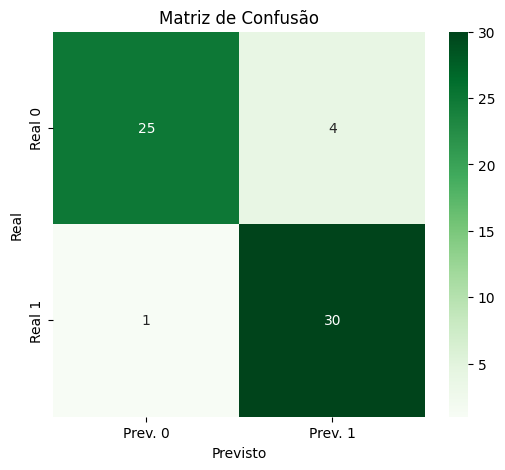


Dados com mais features informativas: 



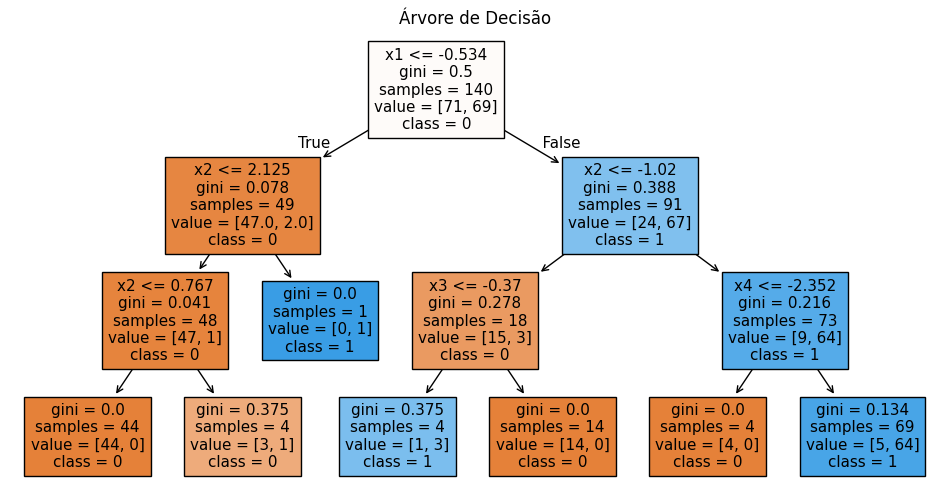


Não é possível plotar a fronteira de decisão em mais de 2 dimensões! 



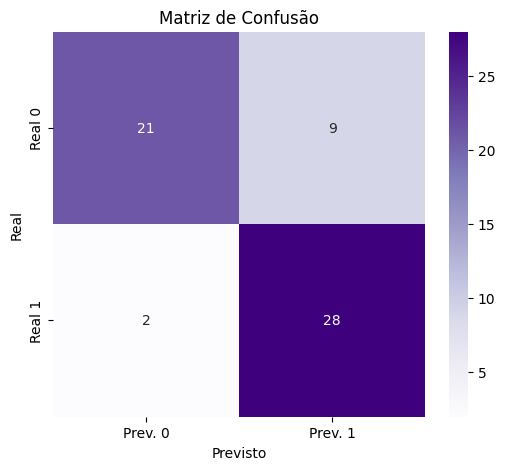

,Conjunto,Accuracy,Precisão,Recall,F1-score
0,Segundo Conjunto,0.917,0.882,0.968,0.923
1,Primeiro Conjunto,0.850,0.788,0.929,0.852
2,Terceiro Conjunto,0.817,0.757,0.933,0.836



Pergunta Final: 
O modelo obteve os melhores resultados para o segundo conjunto de dados (Mais clusters por classe), resultados medianos para o primeiro conjunto de dados (Maior ruído) 
e piores resultados para o terceiro conjunto de dados (Mais features informativas).
O modelo obteve bons resultados no segundo conjunto, pois mesmo que o aumento de clusters torne a fronteira de decisão mais complexa, ela ainda permance estruturada, 
o que viabilizou a generalização dos padrões do dataset mesmo com uma árvore de profundidade bem limitada.
Já para o primeiro conjunto, o modelo obteve resultados medianos, pois o aumento do ruído provocou a ocorrência de rótulos incorretos no dataset, 
que não puderam ser generalizados tão bem assim pelo modelo, devido a árvore utilizada possuir uma profundidade insuficiente.
Por fim, para o terceiro conjunto, o aumento da dimensionalidade causado pelo aumento do número de features, tornou o espaço de busca mais complexo, 
o que dificultou muito a identif

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =====================================================
# 1) Gera dados simples
# =====================================================
# Dados com o ruído dos rótulos (flip_y) aumentado
X1, y1 = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, flip_y=0.15, random_state=0)

# Dados com o número de clusters por classe aumentado
X2, y2 = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=2, random_state=0)

# Dados com o número de features aumentado
X3, y3 = make_classification(n_samples=200, n_features=4,
                           n_redundant=0, n_informative=4,
                           n_clusters_per_class=1, random_state=0)

# Salva os dados gerados em uma lista para evitar repetição ao longo das próximas etapas
lista = [(X1, y1, "Primeiro Conjunto", "Blues"), (X2, y2, "Segundo Conjunto", "Greens"), (X3, y3, "Terceiro Conjunto", "Purples")]

# Cria uma lista para armazenar o resultado do modelo treinado com os diferentes dados
results = []

# Percorre o mesmo treinamento para os diferentes dados gerados
for i in range(3):
  if i == 0:
    print("Dados com maior ruído: \n")
  elif i == 1:
    print("Dados com mais clusters por classe: \n")
  else:
    print("Dados com mais features informativas: \n")

  # =====================================================
  # 2) Dividir em treino e teste
  # =====================================================
  # Divisão dos dados de exemplo entre treino e teste, de forma a evitar que o modelo fique viciado nos dados com que aprendeu
  X_train, X_test, y_train, y_test = train_test_split(
      lista[i][0], lista[i][1], test_size=0.3, random_state=0
  )

  # =====================================================
  # 3) Treinar a árvore
  # =====================================================
  # Treina o modelo com os dados gerados para a respectiva tentativa
  model = DecisionTreeClassifier(max_depth=3)
  model.fit(X_train, y_train)

  # =====================================================
  # 4) Visualizar a Árvore
  # =====================================================
  # Define dinamicamente o nome das features previstas a fim de adequar a exibição delas aos dados utilizadas a cada iteração
  feature_names = [f"x{i+1}" for i in range(X_train.shape[1])]

  # Exibe a árvore do modelo treinado para esta tentativa
  plt.figure(figsize=(12,6))
  plot_tree(model, filled=True, feature_names=feature_names, class_names=["0","1"])
  plt.title("Árvore de Decisão")
  plt.show()
  print()

  # =====================================================
  # 5) Fronteira de decisão
  # =====================================================
  if X_train.shape[1] == 2:
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

    plt.title("Fronteira de Decisão — Árvore")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()
    print()
  else:
    print("Não é possível plotar a fronteira de decisão em mais de 2 dimensões! \n")

  # =====================================================
  # 6) Matriz de Confusão
  # =====================================================
  y_pred = model.predict(X_test)

  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot=True, fmt="d", cmap=lista[i][3],
              xticklabels=["Prev. 0", "Prev. 1"],
              yticklabels=["Real 0", "Real 1"])

  plt.title("Matriz de Confusão")
  plt.ylabel("Real")
  plt.xlabel("Previsto")
  plt.show()
  print()

  # =====================================================
  # 7) Métricas de avaliação
  # =====================================================

  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  results.append({
    "Conjunto": lista[i][2],
    "Accuracy": acc,
    "Precisão": prec,
    "Recall": rec,
    "F1-score": f1
  })

# Exibe uma tabela com os resultados obtidos pelo modelo treinado com cada um dos datasets
df = pd.DataFrame(results).round(3)
# Ordena o dataframe de acordo com a métrica de F1-score, que poderia ser substituida dependendo da aplicação
df = df.sort_values(by="F1-score", ascending=False, ignore_index=True)
display(df)
print()

# Explicação dos resultados obtidos
print("Pergunta Final: ")
print("O modelo obteve os melhores resultados para o segundo conjunto de dados (Mais clusters por classe), resultados medianos para o primeiro conjunto de dados (Maior ruído) \ne piores resultados para o terceiro conjunto de dados (Mais features informativas).")
print("O modelo obteve bons resultados no segundo conjunto, pois mesmo que o aumento de clusters torne a fronteira de decisão mais complexa, ela ainda permance estruturada, \no que viabilizou a generalização dos padrões do dataset mesmo com uma árvore de profundidade bem limitada.")
print("Já para o primeiro conjunto, o modelo obteve resultados medianos, pois o aumento do ruído provocou a ocorrência de rótulos incorretos no dataset, \nque não puderam ser generalizados tão bem assim pelo modelo, devido a árvore utilizada possuir uma profundidade insuficiente.")
print("Por fim, para o terceiro conjunto, o aumento da dimensionalidade causado pelo aumento do número de features, tornou o espaço de busca mais complexo, \no que dificultou muito a identificação dos padrões do dataset com a árvore de baixa profundidade, resultando em um pior desempenho final.")